In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_prep.feature_engineering import load_ml_dataset
from src.models.rule_based import score_rule_based
from src.models.uplift_scoring import add_uplift_scores

In [2]:
CANDIDATE_M = 12
TOP_K_LIST = [1, 3, 5]
MIN_EXPECTED_GAIN = 0.0  # фильтр profitability

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
df = load_ml_dataset()
print("ML dataset:", df.shape)
df.head(3)

ML dataset: (15307, 35)


,client_id,treatment,offer_id,treatment_date,offer_type,offer_category,cost,offer_AOV,channel,conversion,recency_days,frequency_90d,monetary_90d,avg_order_value_lifetime,total_orders_lifetime,days_since_last_promo,discounts_used_90d,avg_discount_percent_90d,favorite_category,visited_category_14d,category_affinity_top1,is_mobile_user,city_tier,email_open_rate_30d,push_enabled,age,gender,price_segment,treatment_dow,treatment_month,treatment_hour,time_morning,time_afternoon,time_evening,time_night
0,17850,1,0,2024-04-12,discount_10,category_0,2.09,18.15,app,0,371,0,0.0,18.15,23,18,0,13.1,category_0,category_0,0.70,0,3,0.98,1,37,F,budget,4,4,0,0,0,0,1
1,17850,0,2,2024-06-28,free_delivery,category_0,3.84,18.15,app,0,371,0,0.0,18.15,27,4,0,16.9,category_0,category_3,0.63,0,3,0.45,1,50,F,budget,4,6,0,0,0,0,1
2,17850,0,2,2024-04-02,free_delivery,category_0,1.44,18.15,web,0,371,0,0.0,18.15,10,18,0,18.8,category_0,category_0,0.77,1,3,0.27,1,39,F,budget,1,4,0,0,0,0,1


In [4]:
df_rule = score_rule_based(df)

need_cols = ["client_id", "offer_id", "rule_score", "p_click_rule", "expected_gain_rule", "conversion", "treatment", "cost", "offer_AOV"]
missing = [c for c in need_cols if c not in df_rule.columns]
if missing:
    raise ValueError(f"score_rule_based() не вернул ожидаемые колонки: {missing}")

df_rule[need_cols].head(5)

,client_id,offer_id,rule_score,p_click_rule,expected_gain_rule,conversion,treatment,cost,offer_AOV
0,17850,0,5.0,0.07,-0.8195,0,1,2.09,18.15
1,17850,2,3.5,0.04,-3.1140,0,0,3.84,18.15
2,17850,2,3.0,0.03,-0.8955,0,0,1.44,18.15
3,17850,1,4.5,0.06,-4.1210,0,0,5.21,18.15
4,13047,1,7.0,0.11,0.0702,0,0,2.00,18.82


In [5]:
def build_candidate_set(df_scored: pd.DataFrame, m: int = 12) -> pd.DataFrame:
    """
    Candidate set одинаковый для всех методов:
    берем top-m по rule_score на каждого клиента.
    """
    parts = []
    for cid, g in df_scored.groupby("client_id", sort=False):
        g2 = g.sort_values("rule_score", ascending=False).head(m)
        parts.append(g2)
    return pd.concat(parts, ignore_index=True) if parts else df_scored.iloc[0:0].copy()

df_candidates = build_candidate_set(df_rule, m=CANDIDATE_M)
print("Candidates:", df_candidates.shape, "unique clients:", df_candidates["client_id"].nunique())
df_candidates[["client_id","offer_id","rule_score","expected_gain_rule"]].head(10)

Candidates: (15307, 38) unique clients: 4338


,client_id,offer_id,rule_score,expected_gain_rule
0,17850,0,5.0,-0.8195
1,17850,1,4.5,-4.1210
2,17850,2,3.5,-3.1140
3,17850,2,3.0,-0.8955
4,13047,2,9.0,-2.8270
5,13047,1,7.0,0.0702
6,12583,0,13.0,-0.3796
7,12583,1,10.5,0.1764
8,12583,2,10.0,-3.0084
9,12583,0,9.5,3.2268


In [6]:
df_uplift = add_uplift_scores(df_candidates)

need_cols_u = ["p_treat", "p_control", "uplift", "expected_gain_uplift"]
missing_u = [c for c in need_cols_u if c not in df_uplift.columns]
if missing_u:
    raise ValueError(f"add_uplift_scores() не вернул ожидаемые колонки: {missing_u}")

df_uplift[["client_id","offer_id","p_treat","p_control","uplift","expected_gain_uplift","conversion","treatment"]].head(5)

,client_id,offer_id,p_treat,p_control,uplift,expected_gain_uplift,conversion,treatment
0,17850,0,0.075141,0.468856,-0.393715,-9.235925,0,1
1,17850,1,0.075465,0.467461,-0.391996,-12.324727,0,0
2,17850,2,0.066981,0.474382,-0.407400,-11.234313,0,0
3,17850,2,0.062413,0.468856,-0.406443,-8.816933,0,0
4,13047,2,0.317084,0.464212,-0.147128,-8.418942,0,1


In [7]:
def select_topk_per_client(
    df_scored: pd.DataFrame,
    score_col: str,
    k: int,
    min_expected_gain: float | None = None,
) -> pd.DataFrame:
    """
    Возвращает выбранные top-k строки на клиента по score_col.
    Если min_expected_gain задан — предварительно фильтруем score_col >= min_expected_gain.
    """
    parts = []
    for cid, g in df_scored.groupby("client_id", sort=False):
        gg = g
        if min_expected_gain is not None:
            gg = gg[gg[score_col] >= float(min_expected_gain)]
        if gg.empty:
            continue
        parts.append(gg.sort_values(score_col, ascending=False).head(k))
    return pd.concat(parts, ignore_index=True) if parts else df_scored.iloc[0:0].copy()

def reject_rate(df_scored: pd.DataFrame, score_col: str, k: int, min_expected_gain: float | None) -> float:
    """
    Доля клиентов, которым ничего не предложили после фильтра.
    """
    total_clients = df_scored["client_id"].nunique()
    picked = select_topk_per_client(df_scored, score_col=score_col, k=k, min_expected_gain=min_expected_gain)
    picked_clients = picked["client_id"].nunique() if not picked.empty else 0
    return 1.0 - (picked_clients / total_clients if total_clients else 0.0)

In [8]:
def compute_topk_metrics(
    df_scored: pd.DataFrame,
    method_name: str,
    score_col: str,
    k_list: list[int],
    min_expected_gain: float | None = None,
) -> pd.DataFrame:
    rows = []
    for k in k_list:
        picked = select_topk_per_client(df_scored, score_col=score_col, k=k, min_expected_gain=min_expected_gain)
        rr = reject_rate(df_scored, score_col=score_col, k=k, min_expected_gain=min_expected_gain)

        if picked.empty:
            rows.append({
                "method": method_name,
                "k": k,
                "ctr@k": np.nan,
                "mean_uplift@k": np.nan,
                "sum_expected_gain": 0.0,
                "mean_expected_gain_per_client": 0.0,
                "sum_cost": 0.0,
                "roi": np.nan,
                "reject_rate": rr,
            })
            continue

        # CTR@k — наблюдаемый (в датасете это click)
        ctr = float(picked["conversion"].mean())

        # mean uplift@k — предсказанный uplift (если есть колонка uplift)
        mean_upl = float(picked["uplift"].mean()) if "uplift" in picked.columns else np.nan

        sum_gain = float(picked[score_col].sum())
        sum_cost = float(picked["cost"].sum()) if "cost" in picked.columns else np.nan

        total_clients = df_scored["client_id"].nunique()
        mean_gain_per_client = sum_gain / total_clients if total_clients else np.nan

        roi = (sum_gain / sum_cost) if (sum_cost and sum_cost > 0) else np.nan

        rows.append({
            "method": method_name,
            "k": k,
            "ctr@k": ctr,
            "mean_uplift@k": mean_upl,
            "sum_expected_gain": sum_gain,
            "mean_expected_gain_per_client": mean_gain_per_client,
            "sum_cost": sum_cost,
            "roi": roi,
            "reject_rate": rr,
        })
    return pd.DataFrame(rows)

# rule-based: сравниваем по expected_gain_rule
metrics_rule_no_filter = compute_topk_metrics(
    df_candidates, method_name="rule_based", score_col="expected_gain_rule",
    k_list=TOP_K_LIST, min_expected_gain=None
)

metrics_rule_profit = compute_topk_metrics(
    df_candidates, method_name="rule_based_profit", score_col="expected_gain_rule",
    k_list=TOP_K_LIST, min_expected_gain=MIN_EXPECTED_GAIN
)

# uplift: сравниваем по expected_gain_uplift
metrics_uplift_no_filter = compute_topk_metrics(
    df_uplift, method_name="uplift", score_col="expected_gain_uplift",
    k_list=TOP_K_LIST, min_expected_gain=None
)

metrics_uplift_profit = compute_topk_metrics(
    df_uplift, method_name="uplift_profit", score_col="expected_gain_uplift",
    k_list=TOP_K_LIST, min_expected_gain=MIN_EXPECTED_GAIN
)

metrics_all = pd.concat([metrics_rule_no_filter, metrics_rule_profit, metrics_uplift_no_filter, metrics_uplift_profit], ignore_index=True)
metrics_all.sort_values(["k","method"])

,method,k,ctr@k,mean_uplift@k,sum_expected_gain,mean_expected_gain_per_client,sum_cost,roi,reject_rate
0,rule_based,1,0.253343,NaN,-2835.802474,-0.653712,30230.93,-0.093805,0.000000
3,rule_based_profit,1,0.319285,NaN,5409.137247,1.246920,13404.16,0.403542,0.458506
6,uplift,1,0.292070,-0.161456,-37714.986414,-8.694096,32546.67,-1.158797,0.000000
9,uplift_profit,1,0.608133,0.150116,10764.627844,2.481473,8360.43,1.287569,0.875288
1,rule_based,3,0.254615,NaN,-44342.750124,-10.221934,119628.19,-0.370671,0.000000
4,rule_based_profit,3,0.338685,NaN,7490.355004,1.726684,26161.14,0.286316,0.458506
7,uplift,3,0.264055,-0.172331,-197112.965115,-45.438673,129651.21,-1.520333,0.000000
10,uplift_profit,3,0.597052,0.148174,12017.670169,2.770325,20203.24,0.594839,0.875288
2,rule_based,5,0.256745,NaN,-72849.189212,-16.793266,168617.40,-0.432038,0.000000
5,rule_based_profit,5,0.340299,NaN,7555.827807,1.741777,26660.21,0.283412,0.458506


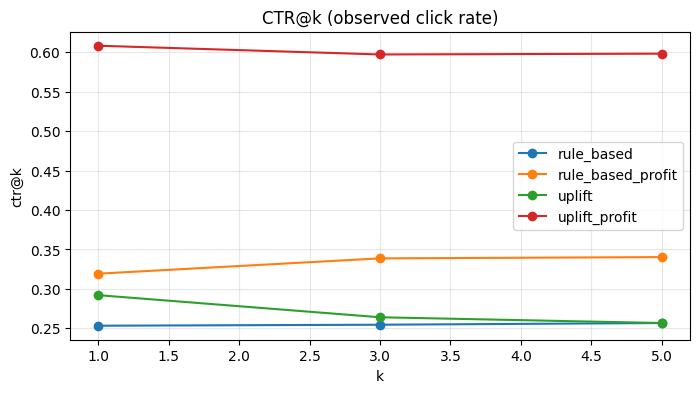

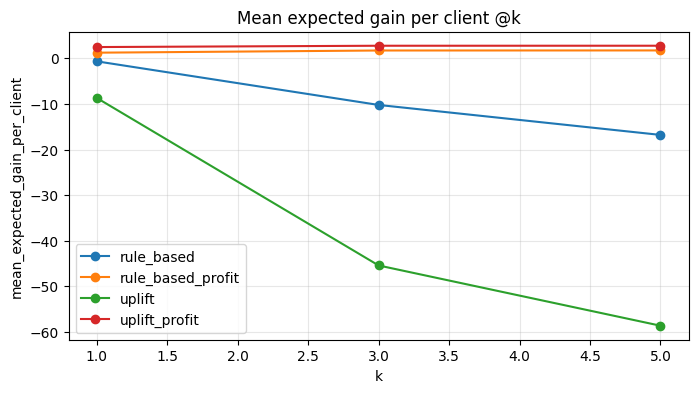

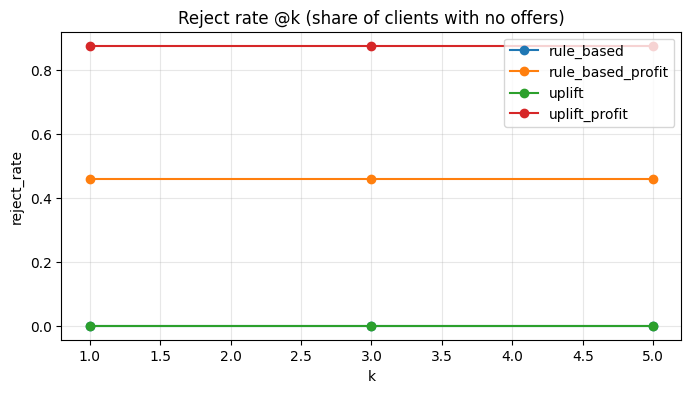

In [9]:
def plot_metric(df_metrics: pd.DataFrame, metric_col: str, title: str):
    plt.figure(figsize=(8, 4))
    for method, g in df_metrics.groupby("method", sort=False):
        plt.plot(g["k"], g[metric_col], marker="o", label=method)
    plt.title(title)
    plt.xlabel("k")
    plt.ylabel(metric_col)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(metrics_all, "ctr@k", "CTR@k (observed click rate)")
plot_metric(metrics_all, "mean_expected_gain_per_client", "Mean expected gain per client @k")
plot_metric(metrics_all, "reject_rate", "Reject rate @k (share of clients with no offers)")

In [10]:
def qini_curve(df_scored: pd.DataFrame, uplift_col: str = "uplift", outcome_col: str = "conversion", treat_col: str = "treatment", n_bins: int = 50):
    """
    Строит Qini curve по строкам:
    - сортируем по uplift (desc)
    - считаем инкрементальные ответы: treated_resp - treated_cnt * (control_resp/control_cnt)
    Для стабильности — считаем в бинах.
    """
    d = df_scored[[uplift_col, outcome_col, treat_col]].dropna().copy()
    d = d.sort_values(uplift_col, ascending=False).reset_index(drop=True)

    if d.empty:
        raise ValueError("Пустой df для qini_curve")

    # биннинг по quantiles (почти равные по размеру)
    d["bin"] = pd.qcut(d.index, q=n_bins, duplicates="drop")
    agg = d.groupby("bin").agg(
        treated_cnt=(treat_col, lambda x: int((x == 1).sum())),
        control_cnt=(treat_col, lambda x: int((x == 0).sum())),
        treated_resp=(outcome_col, lambda y: int(((d.loc[y.index, treat_col] == 1) & (y == 1)).sum())),
        control_resp=(outcome_col, lambda y: int(((d.loc[y.index, treat_col] == 0) & (y == 1)).sum())),
        total_cnt=(outcome_col, "size"),
    ).reset_index(drop=True)

    # cumulative
    agg["cum_treated_cnt"] = agg["treated_cnt"].cumsum()
    agg["cum_control_cnt"] = agg["control_cnt"].cumsum()
    agg["cum_treated_resp"] = agg["treated_resp"].cumsum()
    agg["cum_control_resp"] = agg["control_resp"].cumsum()

    # expected control responses at treated volume
    # (если control_cnt=0 → ожидаем 0)
    rate_control = np.where(
        agg["cum_control_cnt"] > 0,
        agg["cum_control_resp"] / agg["cum_control_cnt"],
        0.0
    )
    agg["qini"] = agg["cum_treated_resp"] - agg["cum_treated_cnt"] * rate_control
    agg["population_share"] = (agg["total_cnt"].cumsum() / agg["total_cnt"].sum())

    return agg

def auuc_from_qini(agg: pd.DataFrame) -> float:
    """
    AUUC как площадь под Qini-кривой по population_share.
    """
    x = agg["population_share"].to_numpy()
    y = agg["qini"].to_numpy()
    if len(x) < 2:
        return float("nan")
    return float(trapezoid(y, x))

/var/folders/jx/v4cj_v_n4kvfz5jphy34_rdw0000gn/T/ipykernel_4689/4111694565.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = d.groupby("bin").agg(


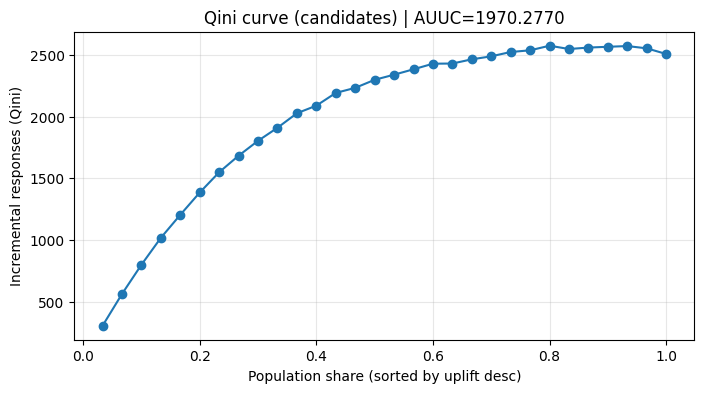

,treated_cnt,control_cnt,treated_resp,control_resp,total_cnt,cum_treated_cnt,cum_control_cnt,cum_treated_resp,cum_control_resp,qini,population_share
25,406,104,55,11,510,10672,2594,3537,238,2557.841943,0.866662
26,405,105,45,10,510,11077,2699,3582,248,2564.180067,0.899980
27,413,97,40,8,510,11490,2796,3622,256,2569.982833,0.933298
28,413,97,24,10,510,11903,2893,3646,266,2551.565849,0.966617
29,416,95,6,12,511,12319,2988,3652,278,2505.854752,1.000000


In [11]:
q = qini_curve(df_uplift, uplift_col="uplift", outcome_col="conversion", treat_col="treatment", n_bins=30)
auuc = auuc_from_qini(q)

plt.figure(figsize=(8,4))
plt.plot(q["population_share"], q["qini"], marker="o")
plt.title(f"Qini curve (candidates) | AUUC={auuc:.4f}")
plt.xlabel("Population share (sorted by uplift desc)")
plt.ylabel("Incremental responses (Qini)")
plt.grid(True, alpha=0.3)
plt.show()

q.tail(5)

In [12]:
def uplift_at_k(df_scored: pd.DataFrame, score_col: str, uplift_col: str, k_list: list[int], min_expected_gain: float | None = None) -> pd.DataFrame:
    rows = []
    for k in k_list:
        picked = select_topk_per_client(df_scored, score_col=score_col, k=k, min_expected_gain=min_expected_gain)
        rows.append({
            "k": k,
            "mean_pred_uplift@k": float(picked[uplift_col].mean()) if (not picked.empty and uplift_col in picked.columns) else np.nan,
            "median_pred_uplift@k": float(picked[uplift_col].median()) if (not picked.empty and uplift_col in picked.columns) else np.nan,
        })
    return pd.DataFrame(rows)

uplift_k_no_filter = uplift_at_k(df_uplift, score_col="expected_gain_uplift", uplift_col="uplift", k_list=TOP_K_LIST, min_expected_gain=None)
uplift_k_profit = uplift_at_k(df_uplift, score_col="expected_gain_uplift", uplift_col="uplift", k_list=TOP_K_LIST, min_expected_gain=MIN_EXPECTED_GAIN)

uplift_k_no_filter, uplift_k_profit

(   k  mean_pred_uplift@k  median_pred_uplift@k
 0  1           -0.161456             -0.255284
 1  3           -0.172331             -0.264322
 2  5           -0.174833             -0.266165,
    k  mean_pred_uplift@k  median_pred_uplift@k
 0  1            0.150116              0.145013
 1  3            0.148174              0.143951
 2  5            0.148657              0.144126)